# Temperature Dataset Modeling
Using Support Vector Regression (SVR) and Random Forest on the temperature dataset.

## Data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data = pd.read_csv('temperature_dataset_full.csv')
data.head()

,Date,Day,GridPoint,Row,Col,TimeTaken,TimeSlot,Temperature_C,Humidity_pct,People,...,RoomLength_m,RoomWidth_m,CeilingHeight_m,GridSize,WindowWidth_m,WindowHeight_m,WindowCount,ReadingHeight_m,FloorMaterial,WallMaterial
0,2026-03-05,Thursday,A1,A,1,08:00,Morning,28.5,78,4,...,11.3,6.64,2.65,4x4,0.6,1.9,12,1.0,Carpet,Concrete/Block
1,2026-03-05,Thursday,A2,A,2,08:03,Morning,28.8,78,4,...,11.3,6.64,2.65,4x4,0.6,1.9,12,1.0,Carpet,Concrete/Block
2,2026-03-05,Thursday,A3,A,3,08:06,Morning,28.8,78,4,...,11.3,6.64,2.65,4x4,0.6,1.9,12,1.0,Carpet,Concrete/Block
3,2026-03-05,Thursday,A4,A,4,08:08,Morning,28.8,79,4,...,11.3,6.64,2.65,4x4,0.6,1.9,12,1.0,Carpet,Concrete/Block
4,2026-03-05,Thursday,B1,B,1,08:09,Morning,28.7,80,4,...,11.3,6.64,2.65,4x4,0.6,1.9,12,1.0,Carpet,Concrete/Block


## Data preparation

In [2]:
# Check for missing values
print("Missing values:\n", data.isnull().sum())

# Drop rows with missing values (if any)
data = data.dropna()

# Output basic information about the dataset
data.info()

Missing values:
 Date                  0
Day                   0
GridPoint             0
Row                   0
Col                   0
TimeTaken             0
TimeSlot              0
Temperature_C         0
Humidity_pct          0
People                0
WindowsOpen           0
OutdoorTemp_C         0
VentilationType      48
CloudCover            0
Rainfall              0
ActiveElectronics     0
DoorStatus            0
SunSide               0
RoomLength_m          0
RoomWidth_m           0
CeilingHeight_m       0
GridSize              0
WindowWidth_m         0
WindowHeight_m        0
WindowCount           0
ReadingHeight_m       0
FloorMaterial         0
WallMaterial          0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 288 entries, 0 to 335
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               288 non-null    object 
 1   Day                288 non-null    object 
 2   G

## Data preprocessing

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

target_col = 'Temperature_C'

# Separate features and target
X = data.drop(columns=[target_col])
y = data[target_col]

# Identify numerical and categorical columns
num_cols = X.select_dtypes(include=['float64', 'int64']).columns
cat_cols = X.select_dtypes(include=['object', 'bool']).columns

# One-hot encode categorical features
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Scale the features (especially important for SVR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'X_train_scaled shape: {X_train_scaled.shape}')
print(f'X_test_scaled shape: {X_test_scaled.shape}')

X_train_scaled shape: (230, 232)
X_test_scaled shape: (58, 232)


## Data Visualization

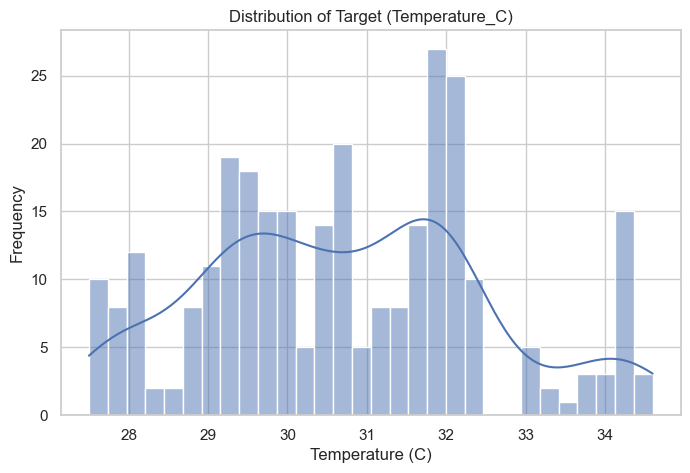

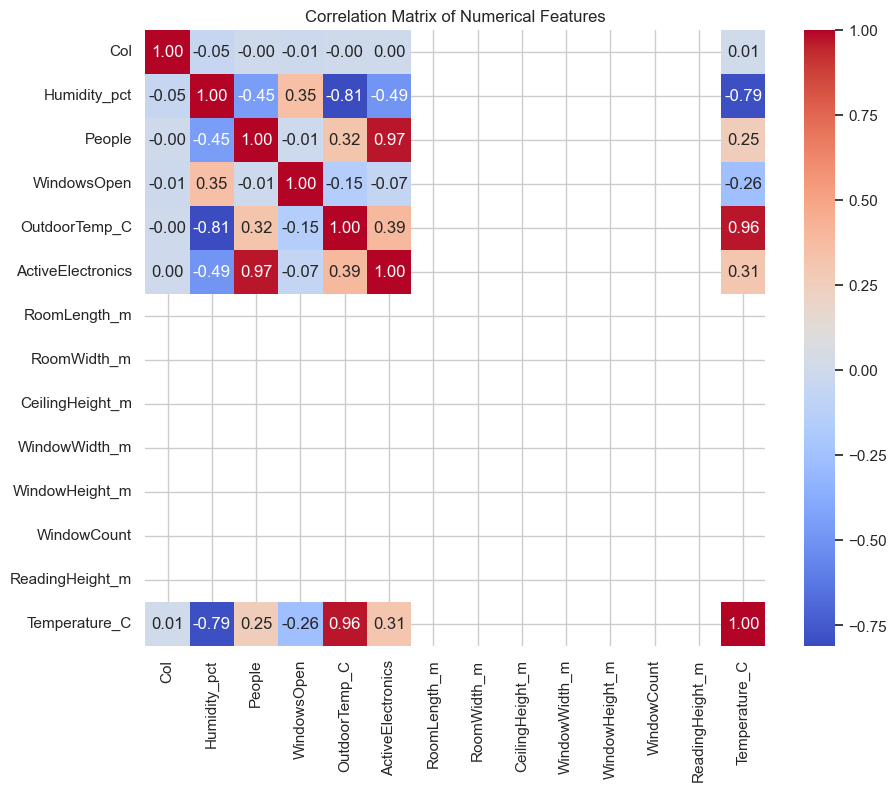

In [4]:
sns.set_theme(style='whitegrid')

# Target variable distribution
plt.figure(figsize=(8, 5))
sns.histplot(y, kde=True, bins=30)
plt.title('Distribution of Target (Temperature_C)')
plt.xlabel('Temperature (C)')
plt.ylabel('Frequency')
plt.show()

# Correlation heatmap for numerical features
plt.figure(figsize=(10, 8))
corr_matrix = data[list(num_cols) + [target_col]].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## Model preparation/ initialization

In [5]:
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

# Initialize the SVR model
svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)

# Initialize the Random Forest Regression model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

print("Models initialized successfully.")

Models initialized successfully.


## Model training

In [6]:
# Train SVR
print("Training SVR model...")
svr_model.fit(X_train_scaled, y_train)
print("SVR training complete.")

# Train Random Forest
print("\nTraining Random Forest model...")
rf_model.fit(X_train_scaled, y_train)
print("Random Forest training complete.")

Training SVR model...
SVR training complete.

Training Random Forest model...
Random Forest training complete.


## Model testing

Model Evaluation Performance:



,Model,MSE,MAE,R2 Score
0,SVR,0.883653,0.597137,0.711879
1,Random Forest,0.032272,0.132707,0.989478


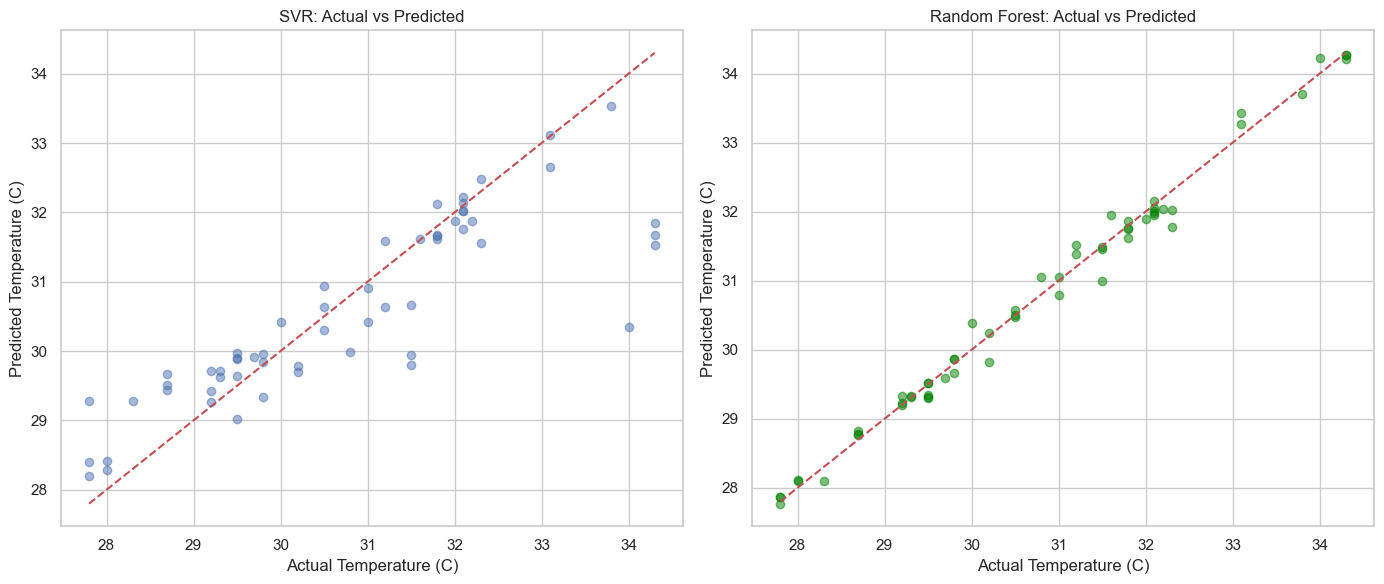

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Generate predictions
svr_preds = svr_model.predict(X_test_scaled)
rf_preds = rf_model.predict(X_test_scaled)

# Calculate evaluation metrics
results = pd.DataFrame({
    'Model': ['SVR', 'Random Forest'],
    'MSE': [
        mean_squared_error(y_test, svr_preds),
        mean_squared_error(y_test, rf_preds)
    ],
    'MAE': [
        mean_absolute_error(y_test, svr_preds),
        mean_absolute_error(y_test, rf_preds)
    ],
    'R2 Score': [
        r2_score(y_test, svr_preds),
        r2_score(y_test, rf_preds)
    ]
})
print("Model Evaluation Performance:\n")
display(results)

# Plotting predictions vs actual values
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_test, svr_preds, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('SVR: Actual vs Predicted')
plt.xlabel('Actual Temperature (C)') 
plt.ylabel('Predicted Temperature (C)')

plt.subplot(1, 2, 2)
plt.scatter(y_test, rf_preds, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Random Forest: Actual vs Predicted')
plt.xlabel('Actual Temperature (C)')
plt.ylabel('Predicted Temperature (C)')

plt.tight_layout()
plt.show()